# **Procesamiento y Transformación de Datos**

#### **Nombres:** Ariel Jiménez
#### **Fecha:** 20/12/2025
#### **Carrera:** Ciencia de Datos 
#### **Periodo académico:** 2025-2S  
#### **Semestre:** Segundo Semestre C 


## **1. Selección y Carga del Dataset (Palmer Penguins)**

### **Justificación del Dataset**
El conjunto de datos `penguins.csv` comprende registros biométricos de pingüinos, incluyendo medidas morfométricas como la longitud y profundidad del pico, longitud de la aleta y masa corporal, además de variables categóricas (isla, sexo y especie). Este recurso es idóneo para la Ciencia de Datos, ya que permite ejecutar un ciclo de vida analítico completo: desde la limpieza de valores faltantes y el tratamiento de valores atípicos (*outliers*), hasta la codificación de variables cualitativas y la estandarización de características numéricas.

### **Objetivos del Análisis**
El presente estudio se divide en dos enfoques predictivos fundamentales:

1.  **Clasificación (Regresión Logística):** Implementar un modelo para predecir la **especie** del pingüino, analizando la capacidad de discriminación de las variables físicas.
2.  **Regresión (Regresión Lineal):** Estimar la **masa corporal (`body_mass_g`)** mediante variables morfométricas y categóricas, evaluando la relación lineal entre ellas.
3.  **Optimización y Evaluación:** Validar el desempeño de los modelos mediante métricas de error y visualizaciones avanzadas, incluyendo un proceso de **Selección de Características (*Feature Selection*)** para comparar la eficiencia de modelos simplificados frente a los modelos base.

In [61]:
# Importar librerias necesarias
import numpy as np
import pandas as pd
import seaborn as sns
import statistics
from matplotlib import pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression 
from sklearn.metrics import (
    accuracy_score, confusion_matrix, ConfusionMatrixDisplay, classification_report,
    mean_squared_error, mean_absolute_error, r2_score
)
from sklearn.preprocessing import label_binarize
from sklearn.feature_selection import SelectKBest, f_regression, f_classif
from sklearn.metrics import roc_curve, auc


In [2]:
# Carga del dataset y previsualización de las primeras filas
dataframe = pd.read_csv("penguins.csv")
dataframe.head()

,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,1,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,2,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,3,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,4,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,5,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


## **2. Preprocesamiento de Datos (Limpieza y Gestión de Atípicos)**

### **2.1. Revisión Inicial y Calidad del Dataset**

In [3]:
# Validación de dimensiones del dataframe (filas, columnas)
print("Shape:", dataframe.shape)

# Inspección de tipos de variables (int, float, object)
print("\nTipos de datos:")
print(dataframe.dtypes)

# Verificación de datos faltantes para determinar estrategia de limpieza
print("\nNulos por columna:")
print(dataframe.isna().sum())

# Identificación de registros repetidos en el conjunto de datos
print("\nDuplicados:", dataframe.duplicated().sum())

Shape: (344, 9)

Tipos de datos:
Unnamed: 0             int64
species               object
island                object
bill_length_mm       float64
bill_depth_mm        float64
flipper_length_mm    float64
body_mass_g          float64
sex                   object
year                   int64
dtype: object

Nulos por columna:
Unnamed: 0            0
species               0
island                0
bill_length_mm        2
bill_depth_mm         2
flipper_length_mm     2
body_mass_g           2
sex                  11
year                  0
dtype: int64

Duplicados: 0


In [4]:
# Resumen estadístico descriptivo (tendencia central y dispersión)
estadisticas = dataframe.describe()
print (estadisticas.round(2))

       Unnamed: 0  bill_length_mm  bill_depth_mm  flipper_length_mm  \
count      344.00          342.00         342.00             342.00   
mean       172.50           43.92          17.15             200.92   
std         99.45            5.46           1.97              14.06   
min          1.00           32.10          13.10             172.00   
25%         86.75           39.22          15.60             190.00   
50%        172.50           44.45          17.30             197.00   
75%        258.25           48.50          18.70             213.00   
max        344.00           59.60          21.50             231.00   

       body_mass_g     year  
count       342.00   344.00  
mean       4201.75  2008.03  
std         801.95     0.82  
min        2700.00  2007.00  
25%        3550.00  2007.00  
50%        4050.00  2008.00  
75%        4750.00  2009.00  
max        6300.00  2009.00  


In [5]:
# Creación de una copia  para preservar los datos originales
df = dataframe.copy()

### **2.2. Imputación de Valores Faltantes**
Para las variables numéricas (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`), se aplica una **imputación basada en la mediana**. Se opta por esta medida de tendencia central debido a su robustez ante valores extremos, lo que reduce el riesgo de desplazar artificialmente la distribución (a diferencia de la media aritmética).  
Para la variable categórica **`sex`**, se utiliza la **moda** (categoría más frecuente). Este enfoque preserva la estructura discreta del atributo sin introducir sesgos mediante la creación de clases inexistentes.

In [6]:
# Definición de columnas numéricas que requieren tratamiento de valores nulos
imput_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g']

# Imputación de valores faltantes utilizando la mediana de cada columna.
# Se elige la mediana por ser una medida de tendencia central robusta frente a valores atípicos (outliers).
df[imput_cols] = df[imput_cols].fillna(df[imput_cols].median())

In [7]:
# Cálculo de la moda para la variable categórica 'sex' usando el módulo statistics
# La moda representa el valor más frecuente en el conjunto de datos
moda_sex = statistics.mode(df['sex'])

# Visualización de la frecuencia de cada categoría para verificar el valor predominante
print(f"Moda calculada: {moda_sex}")
print(df['sex'].value_counts())

Moda calculada: male
sex
male      168
female    165
Name: count, dtype: int64


In [8]:
# Imputación de valores faltantes en la columna 'sex' utilizando la moda calculada
# Se sustituyen los valores nulos (NaN) por la categoría más frecuente para mantener la consistencia del dataset
df['sex'] = df['sex'].fillna(moda_sex)

In [9]:
# Verificación final de la integridad de los datos
# Se confirma que ya no existen valores nulos en ninguna de las columnas del DataFrame
print(df.isna().sum())

Unnamed: 0           0
species              0
island               0
bill_length_mm       0
bill_depth_mm        0
flipper_length_mm    0
body_mass_g          0
sex                  0
year                 0
dtype: int64


### **2.3. Análisis de Gráficas Exploratorias (EDA)**

* **A) Gráficos de Conteo (`species`, `island`, `sex`):** Permiten evaluar el balance de las clases. Si una especie presentara una frecuencia desproporcionada, el modelo podría desarrollar un sesgo hacia la clase dominante. La observación de esta distribución justifica el uso posterior del parámetro `stratify` en la división del dataset (*train/test split*) para conservar las proporciones originales.

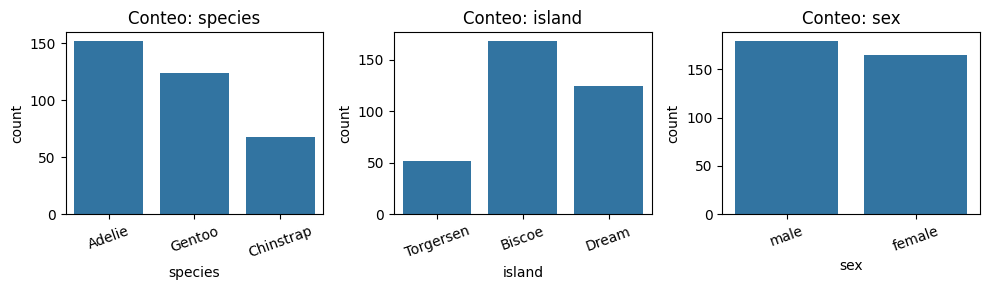

In [10]:
# --- Analisis de variables categoricas (Penguins) ---

# Visualización de la distribución de las variables categóricas mediante gráficos de conteo
# Establece una figura con tres subgráficos para 'species', 'island' y 'sex'
plt.figure(figsize=(10,3))

# Gráfico de conteo para la variable 'species'
plt.subplot(1,3,1)
sns.countplot(x="species", data=df)
plt.title("Conteo: species")
plt.xticks(rotation=20)

# Gráfico de conteo para la variable 'island'
plt.subplot(1,3,2)
sns.countplot(x="island", data=df)
plt.title("Conteo: island")
plt.xticks(rotation=20)

# Gráfico de conteo para la variable 'sex'
plt.subplot(1,3,3)
sns.countplot(x="sex", data=df)
plt.title("Conteo: sex")
plt.xticks(rotation=20)

# Ajuste del diseño y muestra de los gráficos
plt.tight_layout()
plt.show()


* **B) Histogramas de Variables Numéricas:** Las distribuciones reflejan rangos biológicos realistas y permiten detectar asimetrías o colas largas. Por ejemplo, la masa corporal suele mostrar una separación clara entre ciertas especies, sugiriendo que esta variable posee un alto valor informativo para la clasificación taxonómica.

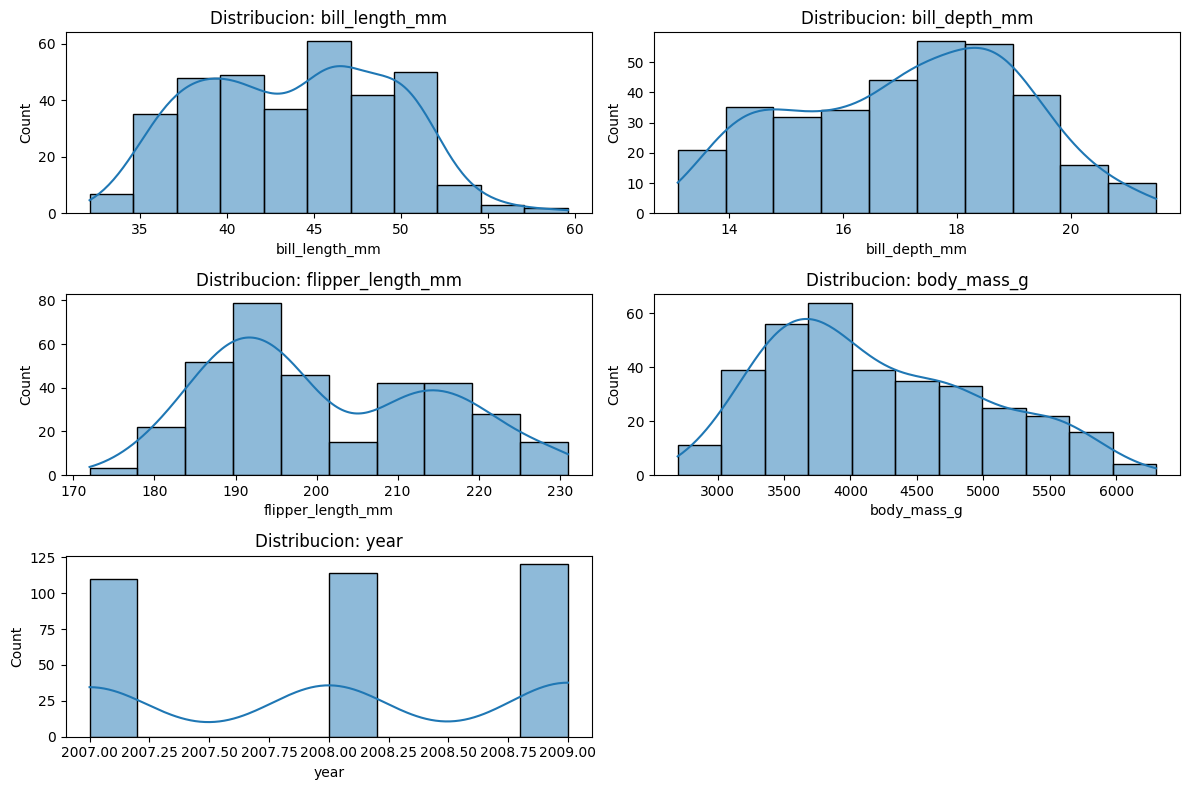

In [11]:
# --- Análisis de Variables Numéricas (Distribución) ---
# Lista de variables cuantitativas a evaluar
num_cols = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g","year"]
plt.figure(figsize=(12,8))

# Bucle para automatizar la creación de histogramas por cada variable
for i,c in enumerate(num_cols,1):
    plt.subplot(3,2,i)
    # Histograma con curva KDE para verificar simetría y normalidad de los datos
    sns.histplot(df[c], kde=True) 
    plt.title(f"Distribucion: {c}")
# Ajuste automático de espacios entre subplots y visualización
plt.tight_layout()
plt.show()

* **C) Histogramas Segmentados por Sexo (`hue="sex"`):** Facilitan la identificación de diferencias sistemáticas vinculadas al dimorfismo sexual. Observar desplazamientos en la masa corporal o longitud de la aleta según el sexo confirma que incluir esta variable en el modelo aportará señal predictiva relevante y reducirá el error residual.

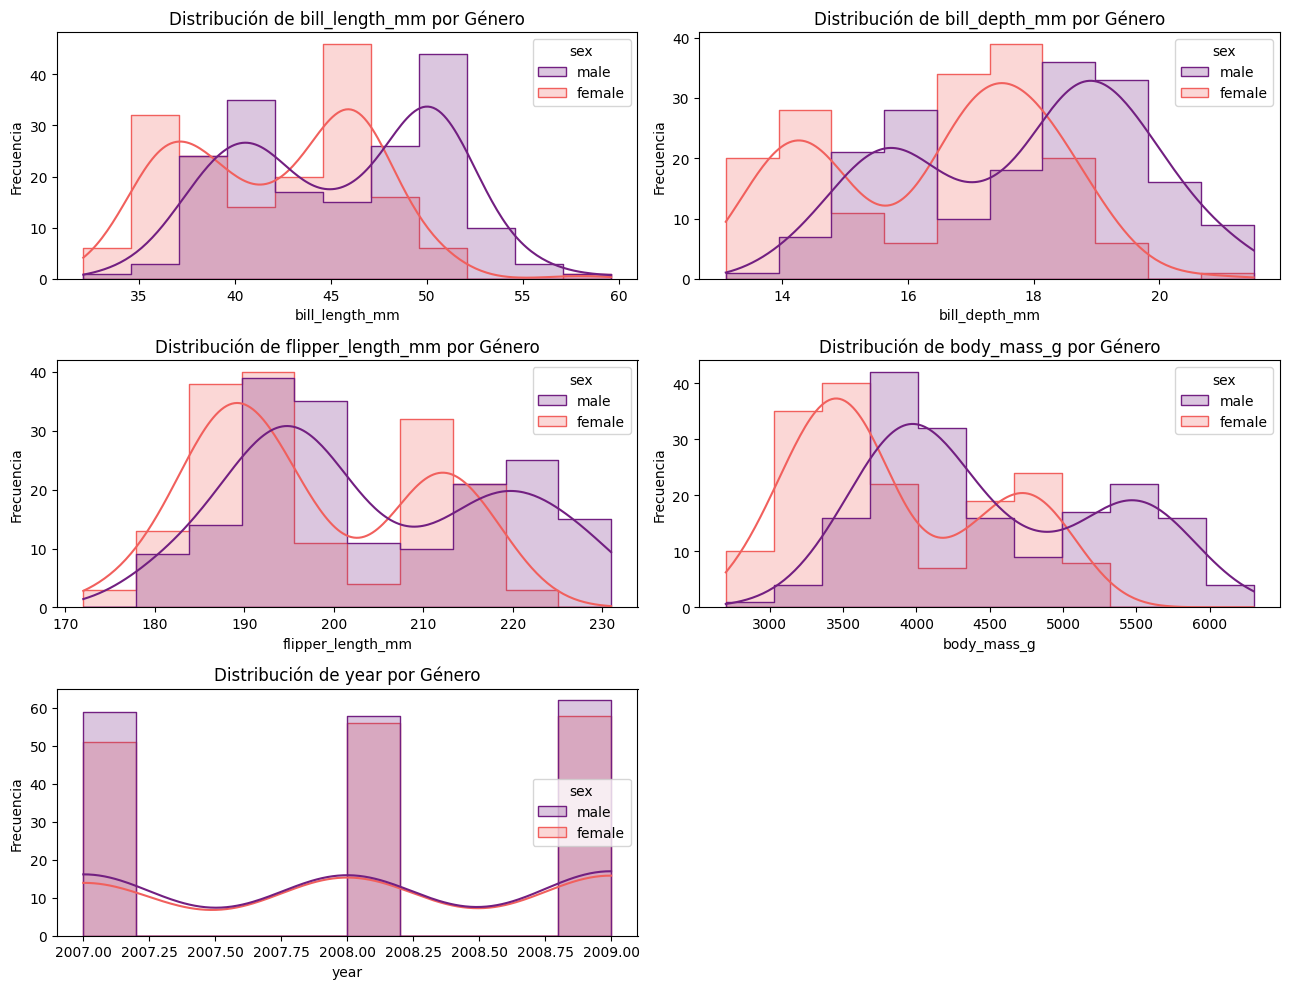

In [12]:
# --- Análisis de Variables Numéricas (Distribución por Género) ---
# Configuración del lienzo para la visualización de histogramas múltiples
plt.figure(figsize=(13, 10))

# Bucle para generar subgráficos comparativos de cada variable numérica
for i, col in enumerate(num_cols, 1):
    # Definición de la cuadrícula de subplots (3 filas, 2 columnas)
    plt.subplot(3, 2, i)
    
    # Creación del histograma con estimación de densidad de kernel (KDE)
    # El parámetro 'hue' permite contrastar las distribuciones entre machos y hembras
    # El estilo 'step' mejora la visibilidad en zonas donde las frecuencias se solapan
    sns.histplot(data=df, x=col, hue="sex", kde=True, element="step", palette="magma")
    
    # Personalización de etiquetas y títulos por cada característica morfométrica
    plt.title(f"Distribución de {col} por Género")
    plt.xlabel(col)
    plt.ylabel("Frecuencia")

# Ajuste automático de espacios para evitar el solapamiento de textos
plt.tight_layout()
plt.show()

* **D) Matriz de correlación:** La matriz de correlación (Pearson) permite identificar relaciones lineales entre variables numéricas. En particular, respecto a `body_mass_g` se observa:

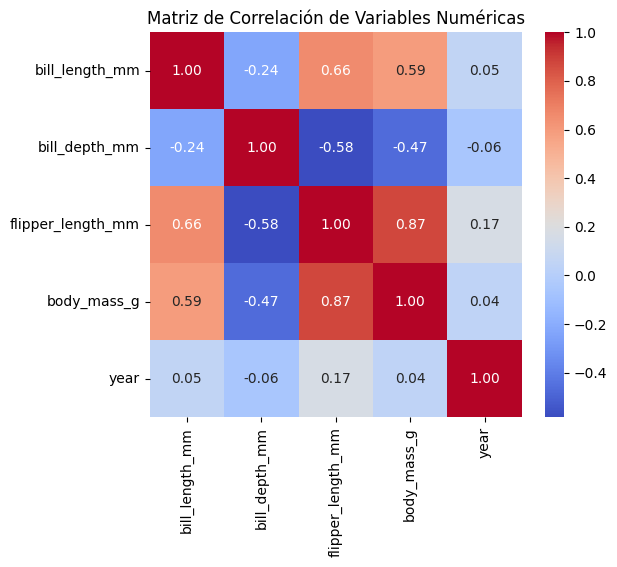

In [13]:
# --- Análisis de relación (correlación) entre variables numéricas ---
# Cálculo de la matriz de correlación de Pearson para identificar dependencias lineales entre características
# Un valor cercano a 1 indica correlación positiva fuerte, mientras que cercano a -1 indica correlación negativa
corr = df[num_cols].corr()

# Configuración y despliegue del mapa de calor (heatmap) para la visualización de la matriz
plt.figure(figsize=(6,5))
# 'annot=True' muestra los valores numéricos; 'cmap="coolwarm"' resalta los extremos de la correlación
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()


* **flipper_length_mm**: correlación positiva fuerte (r ≈ **0.87**).  
    Esto indica que pingüinos con aletas más largas tienden a tener mayor masa corporal, lo cual es coherente biológicamente (tamaño corporal general).

* **bill_length_mm**: correlación positiva moderada (r ≈ **0.59**).  
    Sugiere que picos más largos suelen asociarse a mayor masa, aunque con mayor variabilidad entre especies.

* **bill_depth_mm**: correlación negativa moderada (r ≈ **-0.47**).  
    Esto puede ocurrir porque algunas especies tienen picos más profundos pero no necesariamente mayor masa; es un indicador de que la forma del pico no crece de manera proporcional al peso en todas las especies.

### **2.4. Detección e Interpretación de Outliers**

* **Diagramas de Caja (*Boxplots*) por Sexo:**

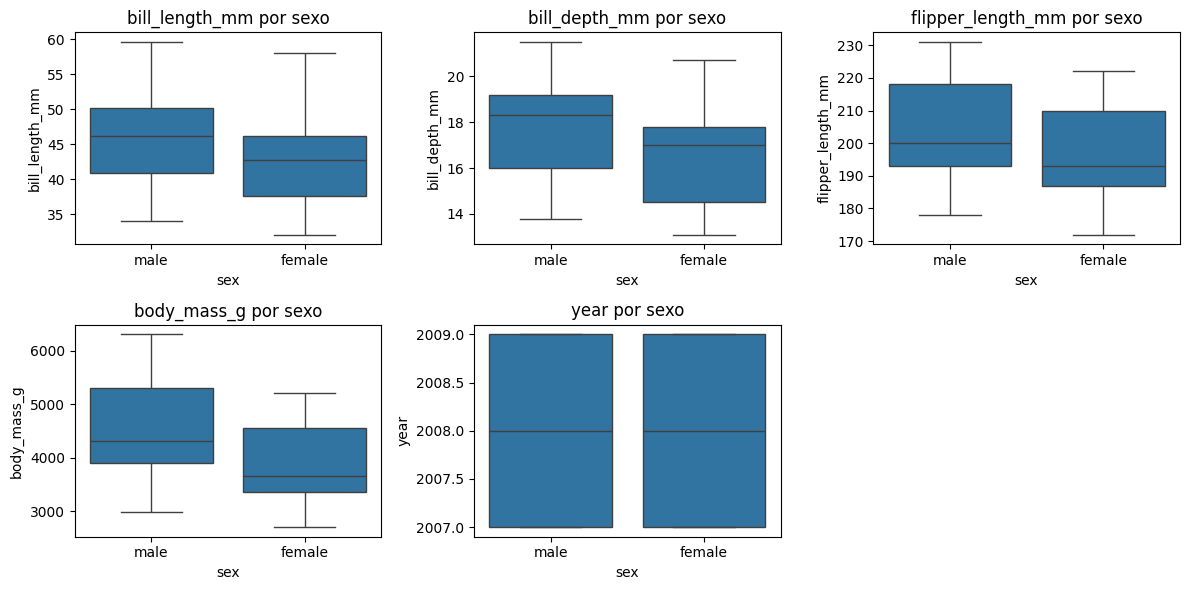

In [14]:
# --- Análisis de Segmentación y Outliers ---
# Configuración del tamaño de la figura para la visualización de diagramas de caja (boxplots)
plt.figure(figsize=(12,6))

# Bucle para generar gráficos descriptivos de cada variable numérica por género
for i, c in enumerate(num_cols, 1):
    # Organización en una cuadrícula de 2 filas y 3 columnas
    plt.subplot(2,3,i)
    
    # El boxplot permite visualizar la mediana, los cuartiles y detectar valores atípicos (outliers)
    # Es fundamental para comparar la dispersión de datos entre 'male' y 'female'
    sns.boxplot(x="sex", y=c, data=df) 
    
    # Asignación de títulos dinámicos basados en la columna analizada
    plt.title(f"{c} por sexo")

# Optimización del espaciado entre subplots para evitar solapamientos de etiquetas
plt.tight_layout()

# Renderizado de los gráficos en el notebook
plt.show()

* A partir de los diagramas de caja (*boxplots*) generados en la fase exploratoria, se observa que las variables numéricas del dataset original no presentan valores atípicos extremos. Las distribuciones se mantienen dentro de rangos biológicamente coherentes, sin identificar observaciones que se alejen de forma significativa de la tendencia central de la población.

* No obstante, en cumplimiento con los requerimientos de la actividad autónoma para demostrar el dominio de técnicas de limpieza, se ha procedido con una **inyección controlada de valores atípicos** sobre una copia del dataset (`df_out`). Permitiendo validar la eficacia del algoritmo de detección basado en el **Rango Intercuartílico (IQR)** y el posterior tratamiento mediante **Winsorización**.

In [15]:
# Creación de una copia del DataFrame original para realizar pruebas de detección de outliers sin alterar los datos base
df_out = df.copy()

# Selección aleatoria de 4 índices para la inyección controlada de valores atípicos (outliers)
# Se utiliza 'random_state' para asegurar que el experimento sea reproducible
idx_outliers = df_out.sample(4, random_state=42).index 

# Inyección manual de valores extremos que superan significativamente los rangos normales (IQR)
# Se asignan medidas atípicas en dimensiones de pico, aletas y masa corporal para simular errores o casos excepcionales
df_out.loc[idx_outliers[0], ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]] = [65, 25, 255, 6800]
df_out.loc[idx_outliers[1], ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]] = [20, 12, 160, 2500]
df_out.loc[idx_outliers[2], ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]] = [60, 26, 265, 7000]
df_out.loc[idx_outliers[3], ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]] = [21, 11.5, 150, 1500]

# Visualización de los índices afectados y de los datos modificados para validar la inserción
print("Indices con outliers inyectados:", idx_outliers.tolist())
df_out.loc[idx_outliers]

Indices con outliers inyectados: [194, 157, 225, 208]


,Unnamed: 0,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
194,195,Gentoo,Biscoe,65.0,25.0,255.0,6800.0,female,2008
157,158,Gentoo,Biscoe,20.0,12.0,160.0,2500.0,female,2007
225,226,Gentoo,Biscoe,60.0,26.0,265.0,7000.0,female,2008
208,209,Gentoo,Biscoe,21.0,11.5,150.0,1500.0,female,2008


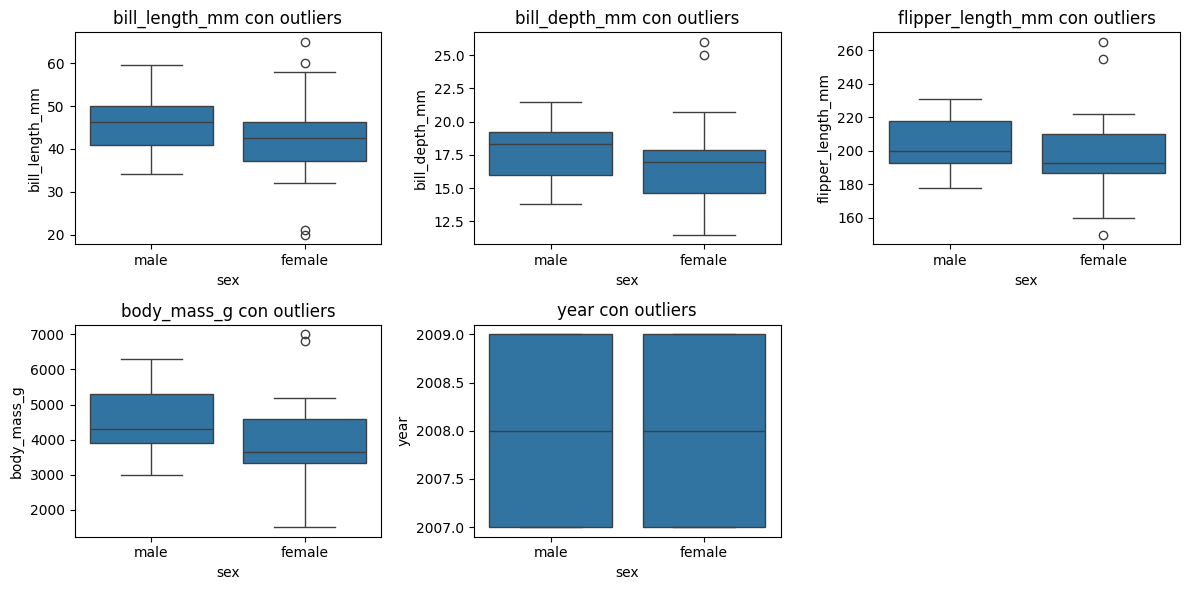

In [16]:
# --- Análisis de Segmentación y Detección de Outliers (Dataset con Ruidos) ---
# Configuración del lienzo para visualizar los diagramas de caja del dataframe con outliers inyectados
plt.figure(figsize=(12,6))

# Bucle para generar boxplots y evaluar visualmente el impacto de los valores atípicos
for i, c in enumerate(num_cols, 1):
    # Definición de la cuadrícula de visualización
    plt.subplot(2,3,i)
    
    # El boxplot destaca los puntos fuera de los "bigotes" como outliers inyectados previamente
    sns.boxplot(x="sex", y=c, data=df_out) 
    
    # Título dinámico para identificar cada característica analizada
    plt.title(f"{c} con outliers")

# Ajuste de diseño para mantener la legibilidad de los ejes y títulos
plt.tight_layout()

# Generación de la gráfica final
plt.show()

### **2.5. Tratamiento de Outliers (IQR + Winsorización)**
Se emplea el método del **Rango Intercuartílico (IQR)** para definir los umbrales de seguridad ($Q1 - 1.5 \times IQR$ y $Q3 + 1.5 \times IQR$). Posteriormente, se aplica **Winsorización (`clip`)**, técnica que ajusta los valores extremos a los límites calculados en lugar de eliminar los registros.

In [17]:
# --- Identificación de Outliers mediante el Método de Rango Intercuartílico (IQR) ---
# Definición de las variables numéricas a evaluar para la detección de valores atípicos
columnas = ["bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"]

# Cálculo de los cuartiles 25% (Q1) y 75% (Q3) para establecer los límites estadísticos
Q1 = df_out[columnas].quantile(0.25)
Q3 = df_out[columnas].quantile(0.75)
IQR = Q3 - Q1

# Definición de los límites inferior (li) y superior (ls)
# Valores fuera de este rango se consideran estadísticamente atípicos
li = Q1 - 1.5 * IQR
ls = Q3 + 1.5 * IQR

print("Límites inferiores calculados:\n", li)
print("Límites superiores calculados:\n", ls)

# Identificación booleana de valores que exceden los límites establecidos
outliers = (df_out[columnas] < li) | (df_out[columnas] > ls)

# Extracción de los índices de las filas que contienen al menos un valor atípico
idx_filas = df_out.index[outliers.any(axis=1)]
print("Filas con outliers detectados:", idx_filas.tolist())

# Visualización de los datos originales (con outliers) antes de aplicar cualquier tratamiento
antes_win = df_out.loc[idx_filas, columnas]
display(antes_win.head(10))

Límites inferiores calculados:
 bill_length_mm         25.2125
bill_depth_mm          11.1375
flipper_length_mm     155.1250
body_mass_g          1740.6250
dtype: float64
Límites superiores calculados:
 bill_length_mm         62.5125
bill_depth_mm          23.2375
flipper_length_mm     248.1250
body_mass_g          6565.6250
dtype: float64
Filas con outliers detectados: [157, 194, 208, 225]


,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
157,20.0,12.0,160.0,2500.0
194,65.0,25.0,255.0,6800.0
208,21.0,11.5,150.0,1500.0
225,60.0,26.0,265.0,7000.0


In [18]:
# --- Tratamiento de Outliers mediante Winsorización (Clipping) ---
# Se limitan los valores extremos a los umbrales estadísticos calculados (li y ls)
# Los valores menores a 'li' se reemplazan por el límite inferior y los mayores a 'ls' por el superior
df_out[columnas] = df_out[columnas].clip(lower=li, upper=ls, axis=1)

# Visualización de los mismos registros tras el tratamiento
post_win = df_out.loc[idx_filas, columnas]
display(post_win.head(10))

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g
157,25.2125,12.0000,160.000,2500.000
194,62.5125,23.2375,248.125,6565.625
208,25.2125,11.5000,155.125,1740.625
225,60.0000,23.2375,248.125,6565.625


### **2.6. Codificacion de Variables y Estandarizacion**

Para preparar el dataset para modelos tanto de clasificación como regresión, se realizan dos transformaciones clave:

**A) Codificacion (One-Hot Encoding)**  
Las variables categoricas (`species`, `island` y `sex`) se convierten a variables binarias (dummies). Esto permite que el modelo interprete categorias como entradas numericas sin imponer un orden artificial entre ellas. Se usa `drop_first=True` para evitar redundancia y reducir colinealidad.

In [19]:
# Selección de columnas previo a la creación de conjuntos de datos para modelos de clasificación y regresión
cols = ["species", "island", "bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g", "sex"]

In [20]:
# Realizar one-hot encoding en las columnas categóricas y mostrar la información del DataFrame resultante
df_encoded=pd.get_dummies(df[cols], columns=["species", "island", "sex"], drop_first=True,dtype=np.float64)
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 344 entries, 0 to 343
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   bill_length_mm     344 non-null    float64
 1   bill_depth_mm      344 non-null    float64
 2   flipper_length_mm  344 non-null    float64
 3   body_mass_g        344 non-null    float64
 4   species_Chinstrap  344 non-null    float64
 5   species_Gentoo     344 non-null    float64
 6   island_Dream       344 non-null    float64
 7   island_Torgersen   344 non-null    float64
 8   sex_male           344 non-null    float64
dtypes: float64(9)
memory usage: 24.3 KB


In [21]:
# Visualización de las primeras filas del DataFrame con variables categóricas codificadas
df_encoded.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_male
0,39.10,18.7,181.0,3750.0,0.0,0.0,0.0,1.0,1.0
1,39.50,17.4,186.0,3800.0,0.0,0.0,0.0,1.0,0.0
2,40.30,18.0,195.0,3250.0,0.0,0.0,0.0,1.0,0.0
3,44.45,17.3,197.0,4050.0,0.0,0.0,0.0,1.0,1.0
4,36.70,19.3,193.0,3450.0,0.0,0.0,0.0,1.0,0.0


**B) Estandarizacion (variables numericas)**  
Las variables numericas (`bill_length_mm`, `bill_depth_mm`, `flipper_length_mm`, `body_mass_g`) se estandarizan para que queden en una escala comparable (media 0 y desviacion 1). Esto es especialmente importante en Regresion Logistica y en modelos lineales, ya que evita que una variable con magnitud mayor domine el ajuste.

In [ ]:
# Estandarizacion consistente: primero se calculan parametros globales y luego se aplican
def ajustar_estandarizacion(X: pd.DataFrame):
    """Calcula la media y desviación estándar de cada columna del DataFrame X."""
    mu = X.mean() # Promedio de cada columna
    sigma = X.std(ddof=0).replace(0, 1) # Desviación estándar de cada columna (evita división por cero)
    return mu, sigma # Retorna las series de medias y desviaciones estándar

# Aplica la estandarización a un DataFrame X usando media y desviación estándar dadas
def aplicar_estandarizacion(X: pd.DataFrame, mu: pd.Series, sigma: pd.Series):
    """Estandariza el DataFrame X usando la media y desviación estándar proporcionadas."""
    return (X - mu) / sigma # Retorna el DataFrame estandarizado


In [23]:
# Lista de columnas numéricas a estandarizar
cols_estandarizar = ["bill_length_mm","bill_depth_mm","flipper_length_mm","body_mass_g"]

In [ ]:
# Cálculo de parámetros globales para estandarización
mu_global, sigma_global = ajustar_estandarizacion(df_encoded[cols_estandarizar])
# Estandarización de las columnas numéricas seleccionadas
# Se pasa el subconjunto del DataFrame que contiene solo las columnas numéricas
# La función 'aplicar_estandarizacion' utiliza los parámetros globales calculados previamente
df_encoded[cols_estandarizar] = aplicar_estandarizacion(df_encoded[cols_estandarizar], mu_global, sigma_global)

In [25]:
# Visualización de las primeras filas del DataFrame con variables categóricas codificadas
df_encoded.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_male
0,-0.887622,0.787289,-1.420541,-0.564625,0.0,0.0,0.0,1.0,1.0
1,-0.814037,0.126114,-1.063485,-0.502010,0.0,0.0,0.0,1.0,0.0
2,-0.666866,0.431272,-0.420786,-1.190773,0.0,0.0,0.0,1.0,0.0
3,0.096581,0.075255,-0.277964,-0.188936,0.0,0.0,0.0,1.0,1.0
4,-1.329133,1.092447,-0.563608,-0.940314,0.0,0.0,0.0,1.0,0.0


## **3. Implementación del Modelo de Clasificación: Regresión Logística**

### **Selección de la Variable Objetivo (*Target*)**
Se ha definido la columna `species` como la variable objetivo. Dado que esta variable es de naturaleza categórica y comprende tres clases distintas (*Adelie, Chinstrap y Gentoo*), se implementa una **Regresión Logística con enfoque multiclase**. Este algoritmo es idóneo para modelar la probabilidad de pertenencia a una categoría específica basándose en la combinación lineal de las características del espécimen.

### **Variables Predictoras (*Features*) y Justificación**
* **Medidas Morfométricas:** `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y `body_mass_g`. Estas dimensiones físicas son indicadores biológicos clave de la divergencia evolutiva entre especies.
* **Atributos Categóricos:** `island` y `sex`, procesados mediante *One-Hot Encoding*. La inclusión del sexo permite controlar el dimorfismo sexual, mientras que la isla de procedencia captura posibles variaciones geográficas en el desarrollo de los pingüinos.

El uso de un modelo logístico tras la estandarización (*Z-score*) garantiza que los coeficientes sean interpretables, permitiendo identificar qué variables tienen mayor peso en la distinción taxonómica.

In [26]:
# --- Preparación de Variables Categóricas y División de Datos ---
# Conversión de variables categóricas en dummies (binarias)
# 'drop_first=True' elimina la primera columna de cada categoría para evitar la multicolinealidad
X_clf = df_encoded.drop(columns=["species_Chinstrap", "species_Gentoo"])
# Definición de la variable objetivo (target) para clasificación
y_clf = df["species"]

In [27]:
# Visualización de las primeras filas de las variables predictoras
X_clf.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_male
0,-0.887622,0.787289,-1.420541,-0.564625,0.0,1.0,1.0
1,-0.814037,0.126114,-1.063485,-0.502010,0.0,1.0,0.0
2,-0.666866,0.431272,-0.420786,-1.190773,0.0,1.0,0.0
3,0.096581,0.075255,-0.277964,-0.188936,0.0,1.0,1.0
4,-1.329133,1.092447,-0.563608,-0.940314,0.0,1.0,0.0


In [28]:
# Visualización de las primeras filas de la variable objetivo
y_clf.head()

0    Adelie
1    Adelie
2    Adelie
3    Adelie
4    Adelie
Name: species, dtype: object

In [29]:
# División del dataset: 80% entrenamiento y 20% prueba mediante train_test_split
# Se obtienen conjuntos separados para evaluar el rendimiento del modelo como clasificación
# 'test_size=0.2' indica que el 20% de los datos se reservarán para pruebas
# 'random_state=42' asegura la reproducibilidad de la división
# 'stratify=y_clf' garantiza que la distribución de especies sea proporcional en ambos conjuntos
X_train_clf, X_test_clf, y_train_clf, y_test_clf = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42, stratify=y_clf
) 

In [30]:
# --- Entrenamiento y Evaluación del Modelo ---
# Instanciación del modelo con solver robusto para problemas de clasificación binaria
# 'max_iter=1000' permite más iteraciones para asegurar la convergencia del modelo
# 'solver' especifica el algoritmo de optimización a utilizar
logreg = LogisticRegression(max_iter=1000, solver='lbfgs')
# Ajuste del modelo a los datos de entrenamiento mediante el método fit()
# Se pasa el conjunto de entrenamiento (features y etiquetas) para que el modelo aprenda los patrones
logreg.fit(X_train_clf, y_train_clf)

,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add a L2 penalty term and it is the default choice;- `'l1'`: add a L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'` and `l1_ratio` set to any float between 0 and 1 for `'penalty='elasticnet'`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation `) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary ` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is 'lbfgs'.To choose a solver, you might want to consider the following aspects:- 'lbfgs' is a good default solver because it works reasonably well for a wide class of problems.- For :term:`mul

In [31]:
# Generación de predicciones sobre el conjunto de test
# Aquí se evalúa el rendimiento del modelo en datos no vistos durante el entrenamiento
clf_pred = logreg.predict(X_test_clf)

Accuracy: 1.0


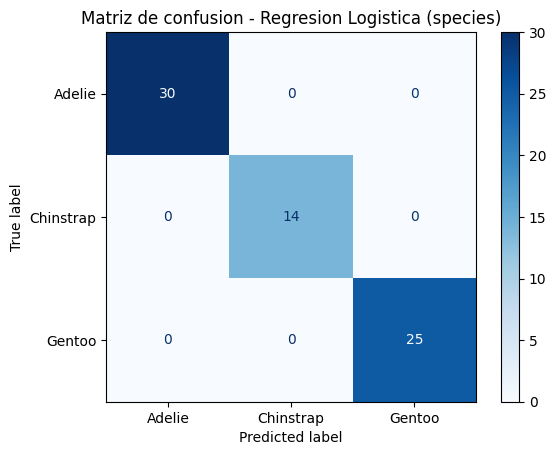


Classification report:
              precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



In [32]:
# Calculo del accuracy (exactitud global del modelo)
# Para accuracy, se compara el número de predicciones correctas con el total de predicciones realizadas
accuracy_clf = accuracy_score(y_test_clf, clf_pred)
print("Accuracy:", accuracy_clf)

# Matriz de confusion (multiclase) con etiquetas reales
labels = logreg.classes_ # Obtiene las clases únicas del modelo entrenado
cm = confusion_matrix(y_test_clf, clf_pred, labels=labels) # Matriz de confusión basada en etiquetas reales y predichas

# Visualización de la matriz de confusión utilizando un mapa de calor
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)
# Muestra la matriz de confusión con un esquema de colores azul 
disp.plot(cmap="Blues")
plt.title("Matriz de confusion - Regresion Logistica (species)")
plt.show()

print("\nClassification report:")
# Reporte detallado de métricas por clase: precisión, recall y F1-score
print(classification_report(y_test_clf, clf_pred, target_names=labels))


In [33]:
# --- Análisis ROC Multiclase (One-vs-Rest) ---
# Binarización de etiquetas y cálculo de probabilidades para evaluar la capacidad de discriminación
# Obtiene las clases únicas presentes en el conjunto de entrenamiento
classes = np.unique(y_train_clf) 
# 'label_binarize' convierte las etiquetas en formato binario para ROC
y_test_bin = label_binarize(y_test_clf, classes=classes) 
# Se pasa el conjunto de prueba para obtener las probabilidades predichas por clase
proba = logreg.predict_proba(X_test_clf) 

In [34]:
print(classes)

['Adelie' 'Chinstrap' 'Gentoo']


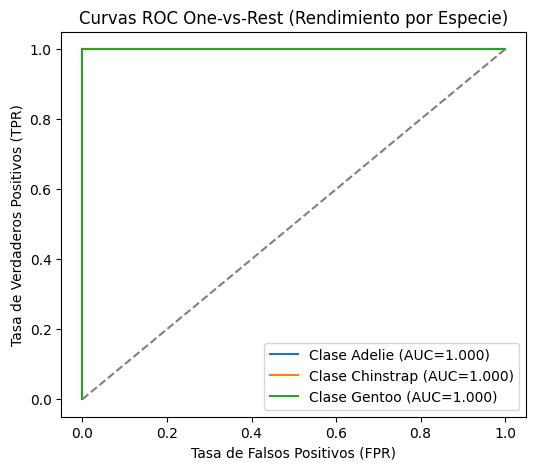

In [35]:
# Se utiliza el enfoque "One-vs-Rest" para evaluar la capacidad de clasificación en un entorno multiclase
plt.figure(figsize=(6,5))

# Iteración sobre cada especie (clase) para calcular su curva individual
for i, c in enumerate(classes):
    # Cálculo de la Tasa de Falsos Positivos (FPR) y Tasa de Verdaderos Positivos (TPR)
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], proba[:, i])
    # Cálculo del Área Bajo la Curva (AUC), que mide la separación entre clases (ideal = 1.0)
    roc_auc = auc(fpr, tpr)
    
    # Graficado de la curva específica para cada especie de pingüino
    plt.plot(fpr, tpr, label=f"Clase {c} (AUC={roc_auc:.3f})")

# Dibujo de la línea de referencia diagonal (clasificador aleatorio)
plt.plot([0,1],[0,1], linestyle="--", color="gray")

# Configuración de etiquetas y leyenda para interpretación de sensibilidad y especificidad
plt.xlabel("Tasa de Falsos Positivos (FPR)")
plt.ylabel("Tasa de Verdaderos Positivos (TPR)")
plt.title("Curvas ROC One-vs-Rest (Rendimiento por Especie)")
plt.legend()
plt.show()

### **Evaluación de Clasificación: Curvas ROC (OvR) y matriz de confusión**

En clasificación multiclase, la curva ROC se calcula con el enfoque **One-vs-Rest (OvR)**: se toma cada especie como clase positiva y las demás como negativas. El resultado de AUC = 1.000 en las curvas ROC One-vs-Rest indica que, para el conjunto de prueba, el modelo logra una separación perfecta entre cada especie y el resto. Este comportamiento es consistente con el dataset Palmer Penguins, donde existe una separación morfométrica fuerte entre especies, especialmente a traves de variables como `flipper_length_mm`, `bill_length_mm` y `bill_depth_mm`.

La matriz de confusión complementa la interpretación porque muestra en qué especies el modelo se confunde con mayor frecuencia.

---

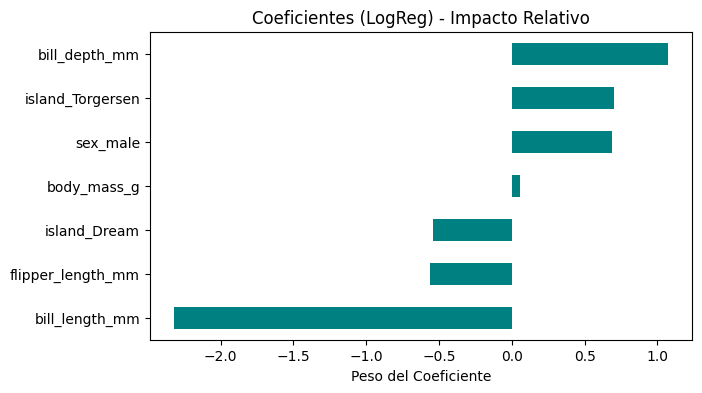

In [36]:
# Visualización de coeficientes: determinan qué variables pesan más en la decisión del modelo
# Extracción y ordenamiento de coeficientes del modelo
coef = pd.Series(logreg.coef_[0], index=X_train_clf.columns).sort_values()
# Ajuste del tamaño del lienzo para la gráfica de barras horizontales
plt.figure(figsize=(7,4))
# Gráfica de barras horizontales para visualizar el impacto relativo de cada variable
coef.plot(kind="barh", color='teal')
# Título y etiquetas descriptivas
plt.title("Coeficientes (LogReg) - Impacto Relativo")
plt.xlabel("Peso del Coeficiente")
# Mostrar la gráfica
plt.show()

### **Coeficientes (LogReg) – Impacto Relativo**

* **Dirección del Impacto:** La orientación de la barra (positiva o negativa) refleja cómo cada variable "empuja" la probabilidad hacia una especie frente a las demás. 
* **Importancia de las Variables:** Las variables morfométricas suelen dominar la gráfica porque capturan diferencias biológicas directas y tangibles. Coeficientes con valores absolutos más grandes (como la longitud de la aleta o la profundidad del pico) indican que esa medida aporta mayor evidencia estadística para distinguir y clasificar correctamente a las especies.
---

## **4. Modelo de Regresión: Regresión Lineal (`body_mass_g`)**

### **Elección de la variable objetivo (*target*)**
Se usa `body_mass_g` como variable objetivo porque es una variable continua que representa la masa corporal del pingüino. El objetivo es aproximar esta masa a partir de medidas morfométricas y variables categóricas.

### **Variables predictoras (*features*)**
Se emplean `bill_length_mm`, `bill_depth_mm`, `flipper_length_mm` y *dummies* de `species`, `island` y `sex`. Estas variables suelen estar relacionadas con el tamaño y la condición corporal del pingüino.

In [37]:
# --- Transformación de categóricas a numéricas mediante One-Hot Encoding ---
# drop_first=True evita la redundancia de datos (multicolinealidad perfecta)
X_reg = df_encoded.drop(columns=["body_mass_g"])

# Definición de la variable dependiente (target): masa corporal (body_mass_g)
y_reg = df["body_mass_g"]

In [38]:
# Visualización de las primeras filas de las variables predictoras
X_reg.head()

,bill_length_mm,bill_depth_mm,flipper_length_mm,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_male
0,-0.887622,0.787289,-1.420541,0.0,0.0,0.0,1.0,1.0
1,-0.814037,0.126114,-1.063485,0.0,0.0,0.0,1.0,0.0
2,-0.666866,0.431272,-0.420786,0.0,0.0,0.0,1.0,0.0
3,0.096581,0.075255,-0.277964,0.0,0.0,0.0,1.0,1.0
4,-1.329133,1.092447,-0.563608,0.0,0.0,0.0,1.0,0.0


In [39]:
# Visualización de las primeras filas de la variable objetivo
y_reg.head()

0    3750.0
1    3800.0
2    3250.0
3    4050.0
4    3450.0
Name: body_mass_g, dtype: float64

In [40]:
# División de datos: 80% entrenamiento para ajustar el modelo y 20% prueba para validar su capacidad de generalización
# 'test_size=0.2' indica que el 20% de los datos se reservarán para pruebas
# 'random_state=42' asegura la reproducibilidad de la división
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [41]:
# --- Entrenamiento del Modelo Lineal ---
# Instanciación del algoritmo de Regresión Lineal (Mínimos Cuadrados Ordinarios)
linearreg = LinearRegression()

# Ajuste del modelo: el algoritmo calcula los coeficientes óptimos para cada variable
# Como parametros se pasan las variables independientes y la variable objetivo del conjunto de entrenamiento
linearreg.fit(X_train_reg, y_train_reg)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [42]:
# Generación de predicciones de masa corporal utilizando los datos que el modelo no ha visto (test)
reg_pred = linearreg.predict(X_test_reg)

In [43]:
# --- Cálculo de Métricas de Error y Ajuste ---
# Error Cuadrático Medio: penaliza más los errores grandes (promedio de errores al cuadrado)
mse_reg = mean_squared_error(y_test_reg, reg_pred)
print("Error Cuadrático Medio:", mse_reg)

# Error Absoluto Medio: promedio simple de la diferencia entre el masa corporal real y el predicho
mae_reg = mean_absolute_error(y_test_reg, reg_pred)
print("Error Absoluto medio:", mae_reg)

# Coeficiente de Determinación (R²): indica qué porcentaje de la varianza del masa corporal explica el modelo
r2_reg = r2_score(y_test_reg, reg_pred)
print("R²:", r2_reg)

# Muestra el peso numérico de cada variable en la ecuación final
print(f'Coeficientes: {linearreg.coef_}')

# Punto donde la línea de regresión corta el eje Y cuando todas las variables son cero
print(f'Intercepto: {linearreg.intercept_}')

Error Cuadrático Medio: 94935.65572367726
Error Absoluto medio: 246.4374681654698
R²: 0.8341172321837428
Coeficientes: [ 143.35555646  137.67763686  246.65197794 -310.19895414  877.43190364
   -6.39623964  -34.37606004  308.13191284]
Intercepto: 3790.929970870302


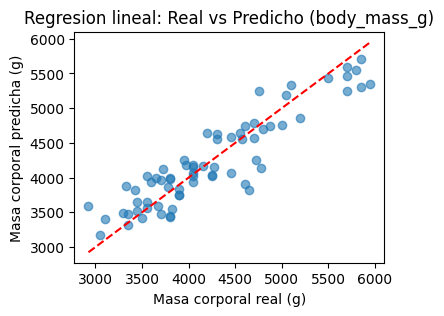

In [44]:
# --- Visualización: Real vs. Predicho (body_mass_g) --- 
plt.figure(figsize=(4,3))
# Gráfico de puntos para ver qué tan cerca están las predicciones de la realidad
plt.scatter(y_test_reg, reg_pred, alpha=0.6)
# Cálculo de límites para trazar la línea ideal de 45 grados
minv = min(y_test_reg.min(), reg_pred.min()) # Valor mínimo entre real y predicho
maxv = max(y_test_reg.max(), reg_pred.max()) # Valor máximo entre real y predicho
# Línea de referencia ideal donde predicho = real
plt.plot([minv,maxv],[minv,maxv], color="red", linestyle="--")
# Etiquetas y título descriptivos
plt.xlabel("Masa corporal real (g)")
plt.ylabel("Masa corporal predicha (g)")
plt.title("Regresion lineal: Real vs Predicho (body_mass_g)")
# Mostrar la gráfica
plt.show()

### **Diagnóstico de Regresión: Real vs. Predicho**

El gráfico Real vs. Predicho compara la masa corporal real con la estimada por el modelo. Si el modelo fuera perfecto, los puntos se alinearían sobre la diagonal (línea de 45 grados). La dispersión alrededor de esa línea indica el nivel de error: mientras más disperso, menor es la capacidad predictiva.

---

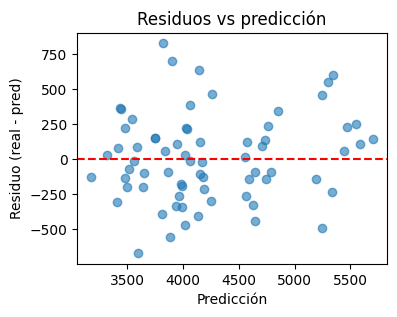

In [45]:
# --- Análisis de Residuos (Errores) ---
# Cálculo de la diferencia individual entre el valor real y la predicción
res = y_test_reg - reg_pred

plt.figure(figsize=(4,3))
# Gráfico para verificar Homocedasticidad (si el error es constante a lo largo de las predicciones)
plt.scatter(reg_pred, res, alpha=0.6)
plt.axhline(0, color="red", linestyle="--") # Línea de error cero
# Etiquetas y título descriptivos
plt.xlabel("Predicción")
plt.ylabel("Residuo (real - pred)")
plt.title("Residuos vs predicción")
# Mostrar la gráfica
plt.show()

### **Análisis de Residuos: Verificación de Supuestos**

Los residuos se definen como: `residuo = valor real - valor predicho`. En una regresión lineal óptima, se espera que:
* **Centro en Cero:** Los residuos deben estar distribuidos alrededor de 0, lo que indica la ausencia de un sesgo sistemático en las estimaciones.
* **Ausencia de Patrones:** No debe existir un patrón claro entre los residuos y las predicciones (homocedasticidad aproximada). 

Si se observa una estructura definida (curva, forma de abanico o tendencia), esto sugiere que la relación entre las variables no es completamente lineal o que existe una varianza no constante, lo cual podría afectar la fiabilidad del modelo.

---

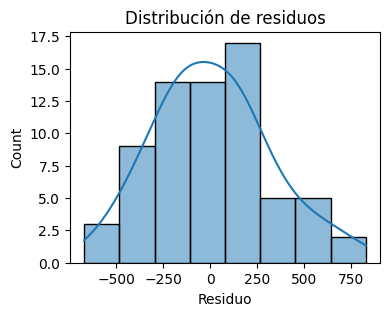

In [46]:
# --- Análisis de Normalidad de Errores ---
plt.figure(figsize=(4,3))
# Histograma de los residuos para verificar si siguen una distribución normal (campana de Gauss)
sns.histplot(res, kde=True)
# Título y etiqueta descriptiva
plt.title("Distribución de residuos")
plt.xlabel("Residuo")
# Mostrar la gráfica
plt.show()

### **Distribución de Residuos**

El histograma (con KDE) permite visualizar si los errores se aproximan a una distribución normal. Si la distribución es aproximadamente simétrica y está centrada en 0, el modelo cumple de mejor manera con el supuesto de normalidad del error. Por el contrario, la presencia de colas largas o asimetría indica que el modelo comete errores significativos en casos específicos.

---

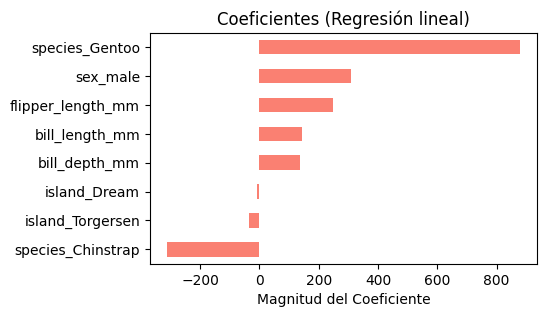

In [47]:
# --- Visualización de Impacto de Variables ---
# Creación de una serie con los coeficientes ordenados para facilitar la interpretación visual
coef_reg = pd.Series(linearreg.coef_, index=X_train_reg.columns).sort_values()
plt.figure(figsize=(5,3))
# Gráfico de barras horizontales: muestra qué variables aumentan o disminuyen la masa corporal predicha
coef_reg.plot(kind="barh", color='salmon')
# Título y etiqueta descriptiva
plt.title("Coeficientes (Regresión lineal)")
plt.xlabel("Magnitud del Coeficiente")
# Mostrar la gráfica
plt.show()

### **Impacto de Coeficientes (Regresión Lineal)**

* **Magnitud e Importancia:** Las variables con barras más largas representan los predictores más influyentes. Por ejemplo, si la longitud de la aleta (`flipper_length_mm`) tiene el coeficiente más alto, significa que es el principal indicador de la masa corporal en el modelo.
* **Sentido de la Relación:** Un coeficiente positivo indica que, a medida que aumenta esa medida física, la masa corporal tiende a aumentar. Por el contrario, un coeficiente negativo (frecuente en algunas variables *dummy*) ajusta la predicción hacia abajo según la especie o el sexo.

---

## **5. Análisis Comparativo y Conclusiones**

### **5.1. Técnicas de Preprocesamiento Clave**
El éxito de los modelos predictivos recae en la integridad de los datos procesados. Se destacan tres pilares:
* **Imputación Estratégica:** El uso de la **mediana** para datos numéricos y la **moda** para categóricos evitó el sesgo que produce la eliminación masiva de registros, preservando la potencia estadística del dataset.
* **Codificación (*One-Hot Encoding*):** La transformación de `species`, `island` y `sex` permitió capturar el **dimorfismo sexual** y la ubicación geográfica como variables numéricas, factores esenciales para explicar la variabilidad de la masa corporal.
* **Estandarización (*Z-Score*):** Al normalizar las escalas, se evitó que variables con magnitudes mayores (como la longitud de aleta en mm) opacaran a otras medidas menores, garantizando que el modelo aprenda de la varianza y no de la escala.

### **5.2. Interpretación Crítica de los Resultados**



#### **A) Clasificación de Especies (Regresión Logística)**
Los resultados muestran un **Accuracy y AUC cercanos al 100%**. Esto indica que las especies de pingüinos de Palmer (*Adelie, Chinstrap y Gentoo*) poseen una diferenciación morfológica tan marcada que el modelo encuentra fronteras de decisión perfectas. La **matriz de confusión** confirma que no existe solapamiento crítico; el modelo distingue con precisión que, por ejemplo, los pingüinos *Gentoo* son significativamente más grandes que los *Adelie*.

#### **B) Predicción de Masa Corporal (Regresión Lineal)**
El modelo de regresión presenta un **$R^2$ robusto**, lo que confirma que las dimensiones físicas (pico y aleta) explican gran parte del peso total. Sin embargo, la dispersión residual sugiere que existen factores no capturados, como la edad o el estado nutricional del individuo. La **longitud de la aleta** se consolida como el predictor más fuerte, validando la hipótesis biológica de que el tamaño de las extremidades está directamente vinculado al volumen corporal total.

---
## **Ejemplos de uso**

### **Regresión Logística**

In [48]:
# Creación de un set de datos ficticio para probar la capacidad predictiva del modelo de clasificación
ejemplos_clf = pd.DataFrame([
    {"island": "Biscoe", "bill_length_mm": 47.0, "bill_depth_mm": 14.5,
     "flipper_length_mm": 220, "body_mass_g": 5400, "sex": "male"},

    # Ejemplo tipo Chinstrap (Dream, pico largo, aleta media, peso medio)
    {"island": "Dream", "bill_length_mm": 50.0, "bill_depth_mm": 18.0,
     "flipper_length_mm": 195, "body_mass_g": 3900, "sex": "female"},

    # Ejemplo tipo Adelie (Dream o Torgersen, pico corto, aleta corta, peso medio-bajo)
    {"island": "Dream", "bill_length_mm": 38.0, "bill_depth_mm": 19.0,
     "flipper_length_mm": 185, "body_mass_g": 3400, "sex": "male"},
])

# Aplicación de One-Hot Encoding a los nuevos ejemplos para igualar el formato del entrenamiento
ej_clf_dummies = pd.get_dummies(
    # DataFrame de nuevos ejemplos
    ejemplos_clf,
    # Columnas categóricas a transformar
    columns=["island", "sex"],
    # drop_first=True evita la redundancia de datos
    drop_first=True
)

# reindex asegura que el orden y cantidad de columnas sean exactamente iguales a las que vio el modelo (X_train_clf)
# fill_value=0 coloca ceros si una categoría del entrenamiento no aparece en estos ejemplos nuevos
ej_clf_dummies = ej_clf_dummies.reindex(columns=X_train_clf.columns, fill_value=0)


In [49]:
# Estandarización de las variables numéricas usando los parámetros globales calculados previamente
ej_clf_dummies[cols_estandarizar]= aplicar_estandarizacion(ej_clf_dummies[cols_estandarizar], mu_global, sigma_global)

In [50]:
# Visualización de los datos de ejemplo ya preparados para la predicción
ej_clf_dummies

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,island_Dream,island_Torgersen,sex_male
0,0.565686,-1.348815,1.364491,1.501663,False,0,True
1,1.117576,0.431272,-0.420786,-0.376781,True,0,False
2,-1.089981,0.939868,-1.134897,-1.002929,True,0,True


In [51]:
# Predicción de la clase final (0 para Clase 0, 1 para Clase 1)
predicciones_ejemplos = logreg.predict(ej_clf_dummies)

# Visualización de los resultados de la inferencia
print("Predicciones (0/1):", predicciones_ejemplos)

Predicciones (0/1): ['Gentoo' 'Chinstrap' 'Adelie']


In [52]:
# Obtención de las probabilidades detalladas para cada clase (confianza del modelo)
proba_specie_1 = logreg.predict_proba(ej_clf_dummies)[:, 0] # Probabilidad de ser clase 0
proba_specie_2 = logreg.predict_proba(ej_clf_dummies)[:, 1] # Probabilidad de ser clase 1
proba_specie_3 = logreg.predict_proba(ej_clf_dummies)[:, 2] # Probabilidad de ser clase 2

print("Probabilidad clase 0:")
print(proba_specie_1)
print("Probabilidad clase 1:")
print(proba_specie_2)
print("Probabilidad clase 2:")
print(proba_specie_3)

Probabilidad clase 0:
[4.60313861e-04 2.79199723e-03 9.92244595e-01]
Probabilidad clase 1:
[4.25935640e-04 9.90639477e-01 7.56567475e-03]
Probabilidad clase 2:
[9.99113750e-01 6.56852617e-03 1.89730510e-04]


### **Regresión Lineal**

In [53]:
# Creacion de perfiles de pinguinos para predecir su masa corporal (body_mass_g)
ejemplos_reg = pd.DataFrame([ 
    {"species": "Adelie",    "island": "Torgersen", "bill_length_mm": 39.1, "bill_depth_mm": 18.7, "flipper_length_mm": 181, "sex": "male"},
    {"species": "Gentoo",    "island": "Biscoe",    "bill_length_mm": 46.5, "bill_depth_mm": 13.5, "flipper_length_mm": 210, "sex": "female"},
    {"species": "Chinstrap", "island": "Dream",     "bill_length_mm": 50.0, "bill_depth_mm": 19.4, "flipper_length_mm": 195, "sex": "female"},
])

# Transformacion de categoricas a dummies para que coincidan con las columnas del entrenamiento
ej_reg_dummies = pd.get_dummies(ejemplos_reg, columns=["species", "island", "sex"], drop_first=True)

# Sincronizar columnas con el modelo (mismas columnas y mismo orden)
ej_reg_dummies = ej_reg_dummies.reindex(columns=X_train_reg.columns, fill_value=0)

# Obtiene solo las columnas numéricas para estandarizar de este ejemplo
ej_reg_numeric = ej_reg_dummies.select_dtypes(include='number').columns
# Muestra las columnas numéricas seleccionadas
ej_reg_numeric

Index(['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm'], dtype='object')

In [54]:
# Estandarización de las variables numéricas usando los parámetros globales calculados previamente
ej_reg_dummies[ej_reg_numeric] = aplicar_estandarizacion(ej_reg_dummies[ej_reg_numeric], mu_global[ej_reg_numeric], sigma_global[ej_reg_numeric])
# Visualización de los datos de ejemplo ya preparados para la predicción
ej_reg_dummies

,bill_length_mm,bill_depth_mm,flipper_length_mm,species_Chinstrap,species_Gentoo,island_Dream,island_Torgersen,sex_male
0,-0.887622,0.787289,-1.420541,False,False,False,True,True
1,0.473705,-1.857412,0.650381,False,True,False,False,False
2,1.117576,1.143307,-0.420786,True,False,True,False,False


In [55]:
# Predicción de masa corporal
pred_body_mass = linearreg.predict(ej_reg_dummies)

print("Masa corporal predicha (g):", pred_body_mass)

Masa corporal predicha (g): [3695.45322225 4640.96374024 3688.16562058]


---
## **6. Reto Adicional: Feature Selection**

### **Regresión logística**

In [ ]:
# --- Selección de Características (Feature Selection) para Clasificación ---
k_best = 3 # Definición del número de variables con mayor relevancia estadística a conservar 

# Instanciación de SelectKBest utilizando ANOVA (f_classif) como prueba de significancia
# Esta prueba evalúa si las medias de las variables numéricas varían significativamente entre las especies
# 'socre_func=f_classif' especifica la función estadística a utilizar
selector_clf = SelectKBest(score_func=f_classif, k=k_best)

# Ajuste del selector: el modelo "aprende" cuáles son las variables más informativas del set de entrenamiento
# Se pasan las variables independientes y la variable objetivo del conjunto de entrenamiento
X_train_clf_fs = selector_clf.fit_transform(X_train_clf, y_train_clf)

# Transformación del set de prueba para asegurar que tenga la misma estructura (mismas columnas) que el entrenamiento
X_test_clf_fs = selector_clf.transform(X_test_clf)

# Identificación de las variables ganadoras mediante una máscara booleana
mask_clf = selector_clf.get_support() # Obtiene un array booleano indicando qué características fueron seleccionadas
features_selec_clf = X_train_clf.columns[mask_clf] # Extrae los nombres de las características seleccionadas
print(f"Top {k_best} características para Clasificación: {list(features_selec_clf)}") # Muestra las características seleccionadas

Top 3 características para Clasificación: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm']


In [57]:
# --- Re-entrenamiento del Modelo de Clasificación ---
# Instanciación de la Regresión Logística para el nuevo set de datos reducido
logreg_fs = LogisticRegression(max_iter=1000, solver="lbfgs")

# Ajuste del modelo utilizando únicamente las 10 mejores variables seleccionadas
logreg_fs.fit(X_train_clf_fs, y_train_clf)

# Generación de predicciones de género con el modelo optimizado
fs_pred_clf = logreg_fs.predict(X_test_clf_fs)

# Cálculo de la precisión (Accuracy) tras aplicar Feature Selection
accuracy_clf_fs = accuracy_score(y_test_clf, fs_pred_clf)
print("Accuracy con Feature Selection:", accuracy_clf_fs)

# Despliegue de la Matriz de Confusión para ver aciertos y errores en el set reducido
print("Matriz de confusión con FS:\n", confusion_matrix(y_test_clf, fs_pred_clf))

# Reporte detallado de métricas (Precision, Recall, F1) para evaluar el impacto del recorte de variables
print("Reporte de clasificación:\n", classification_report(y_test_clf, fs_pred_clf))

Accuracy con Feature Selection: 1.0
Matriz de confusión con FS:
 [[30  0  0]
 [ 0 14  0]
 [ 0  0 25]]
Reporte de clasificación:
               precision    recall  f1-score   support

      Adelie       1.00      1.00      1.00        30
   Chinstrap       1.00      1.00      1.00        14
      Gentoo       1.00      1.00      1.00        25

    accuracy                           1.00        69
   macro avg       1.00      1.00      1.00        69
weighted avg       1.00      1.00      1.00        69



### **Regresión lineal**

In [58]:
# --- Selección de Características para Regresión (Feature Selection) ---
k_reg = 8 # Número de características principales a conservar para el modelo

# Instanciación de SelectKBest utilizando f_regression
# Esta prueba estadística calcula la correlación lineal entre cada variable y el peso (target)
# para determinar su relevancia individual.
# 'score_func=f_regression' especifica la función estadística a utilizar
selector_reg = SelectKBest(score_func=f_regression, k=k_reg)

# Ajuste y transformación del set de entrenamiento para identificar las variables más relevantes
X_train_reg_fs = selector_reg.fit_transform(X_train_reg, y_train_reg)

# Transformación del set de prueba para mantener la coherencia en las características utilizadas
X_test_reg_fs = selector_reg.transform(X_test_reg)

# Identificación de las variables que superaron el filtro mediante una máscara booleana
mask_reg = selector_reg.get_support()

# Recuperación de los nombres de las variables seleccionadas para su interpretación clínica/biológica
features_selec_reg = X_train_reg.columns[mask_reg]
print(f"Top {k_reg} características para Regresión: {list(features_selec_reg)}") # Muestra las características seleccionadas

Top 8 características para Regresión: ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'species_Chinstrap', 'species_Gentoo', 'island_Dream', 'island_Torgersen', 'sex_male']


In [59]:
# --- Re-entrenamiento del Modelo de Regresión ---
# Instanciación de la Regresión Lineal para trabajar con el set reducido
linearreg_fs = LinearRegression()

# Ajuste del modelo: cálculo de la nueva pendiente e intercepto con las k variables
linearreg_fs.fit(X_train_reg_fs, y_train_reg)

# Predicción del masa corporal (body_mass_g) para los datos de prueba reducidos
fs_pred_reg = linearreg_fs.predict(X_test_reg_fs)

# Cálculo del MSE: mide qué tan lejos están las nuevas predicciones del masa corporal real
mse_reg_fs = mean_squared_error(y_test_reg, fs_pred_reg)
print("Error Cuadrático Medio con FS:", mse_reg_fs)

# Cálculo del MAE: error promedio absoluto en gramos con el modelo reducido
mae_reg_fs = mean_absolute_error(y_test_reg, fs_pred_reg)
print("Error Absoluto medio con FS:", mae_reg_fs)

# Cálculo del R²: porcentaje de varianza explicada por el modelo con Feature Selection
r2_reg_fs = r2_score(y_test_reg, fs_pred_reg)
print("R² con FS:", r2_reg_fs)

# Muestra de los nuevos coeficientes asignados a las k variables elegidas
print(f'Coeficientes: {linearreg_fs.coef_}')

# Muestra del nuevo intercepto de la recta de regresión
print(f'Intercepto: {linearreg_fs.intercept_}')

Error Cuadrático Medio con FS: 94935.65572367726
Error Absoluto medio con FS: 246.4374681654698
R² con FS: 0.8341172321837428
Coeficientes: [ 143.35555646  137.67763686  246.65197794 -310.19895414  877.43190364
   -6.39623964  -34.37606004  308.13191284]
Intercepto: 3790.929970870302


In [60]:
# --- Resumen Final de Rendimiento ---
# Creación de un DataFrame para consolidar y comparar los resultados de todos los experimentos
comparacion = pd.DataFrame({
    # Etiquetas de los 4 modelos entrenados
    "Modelo": ["LogReg (base)", "LogReg (FS)", "LinReg (base)", "LinReg (FS)"],
    
    # Recopilación de las métricas clave para facilitar la lectura del análisis
    "Metricas": [
        f"Accuracy={accuracy_clf:.4f}",       # Resultado clasificación original
        f"Accuracy={accuracy_clf_fs:.4f}",    # Resultado clasificación tras FS
        f"MSE={mse_reg:.2f}, MAE={mae_reg:.2f}, R2={r2_reg:.4f}",       # Regresión original
        f"MSE={mse_reg_fs:.2f}, MAE={mae_reg_fs:.2f}, R2={r2_reg_fs:.4f}" # Regresión tras FS
    ]
})

# Despliegue visual de la tabla comparativa
display(comparacion)

,Modelo,Metricas
0,LogReg (base),Accuracy=1.0000
1,LogReg (FS),Accuracy=1.0000
2,LinReg (base),"MSE=94935.66, MAE=246.44, R2=0.8341"
3,LinReg (FS),"MSE=94935.66, MAE=246.44, R2=0.8341"


### **Implementación de Selección de Características (Feature Selection)**
Se implementó la técnica `SelectKBest` para identificar las $k$ características con mayor poder predictivo, aplicando los siguientes criterios estadísticos:
* **Para Clasificación:** Se utilizó `f_classif` (ANOVA F-test) para capturar las variables que mejor discriminan entre especies.
* **Para Regresión:** Se utilizó `f_regression` para hallar las variables con mayor correlación lineal respecto a la masa corporal.

Este proceso permitió evaluar la capacidad para mantener un rendimiento aceptable reduciendo la dimensionalidad y la complejidad computacional.

### **Impacto de la Selección de Características**
Tras aplicar la reducción de variables, se observa que el rendimiento de los modelos se mantiene. Este fenómeno demuestra la existencia de **multicolinealidad** en el dataset (por ejemplo, la alta correlación entre la longitud de la aleta y el tamaño del pico). Eliminar variables redundantes no solo simplifica el modelo, sino que mitiga el riesgo de **sobreajuste (*overfitting*)** y mejora la interpretación de los predictores clave sin sacrificar la capacidad predictiva.



## **Conclusiones**

1. **Fiabilidad del Modelo:** El flujo de Ciencia de Datos aplicado —desde la limpieza y winsorización hasta la estandarización— garantiza que las inferencias obtenidas no son producto del azar, sino de una estructura de datos estadísticamente limpia y bien transformada.
2. **Valor Biológico:** El análisis confirma que el **dimorfismo sexual y la taxonomía** son los motores principales de la variación física en los pingüinos. Las medidas morfométricas son descriptores altamente efectivos de la identidad de la especie.
3. **Reflexión Final:** Aunque la clasificación es perfecta, la regresión lineal para la masa corporal presenta ligeros márgenes de error. Esto sugiere que el modelo podría optimizarse en futuros trabajos mediante algoritmos no lineales (como *Random Forest* o *XGBoost*), dado que las relaciones biológicas no siempre siguen una progresión aritmética exacta.